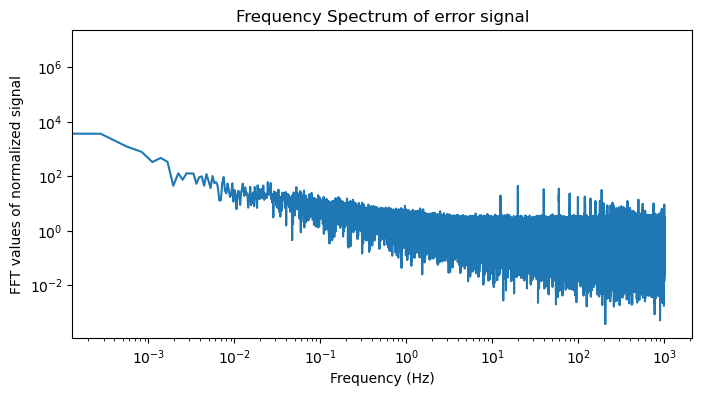

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

data = np.dtype([('ch0', 'float32'),('ch1', 'float32')])
signaltot = np.fromfile('C:/Users/hodei/OneDrive/python-programak/mephis2absat_pslockedkp16ki5rin7200_100mw_0_1Vrmon1_errors.bin', dtype=data)
signal = signaltot['ch1']#[:180000000]
n = 50
sampl_freq = 5e4/n # Max sampling frequency 50 kHz
trimmedlen = len(signal)//n*n
points_matrix = signal[:trimmedlen].reshape(-1,n)
mpoints = points_matrix.mean(axis=1)
points_norm = mpoints/np.mean(mpoints)

# Compute FFT
fft_values = np.fft.fft(points_norm)
freqs = np.fft.fftfreq(len(points_norm), 1/sampl_freq)

# Take only positive frequencies
positive_freqs = freqs[:len(freqs)//2]
magnitude = np.abs(fft_values[:len(freqs)//2])

# Plot
plt.figure(figsize=(8,4))
plt.loglog(2*positive_freqs, magnitude)
plt.title("Frequency Spectrum of error signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT values of normalized signal")
plt.show()
